# 卷积层

1. 卷积层：特征提取器（“找局部特征”）
   
卷积层的意义在于提取图像的局部特征。它通过一个个小窗口（卷积核）在图像上滑动，逐一检查每个小区域。

2. 池化层：降采样器（“浓缩精华”）
   
池化层的意义在于降低数据的空间尺寸（缩小长宽），同时保留最重要的信息。它通常紧跟在卷积层后面。

池化层可以缓解卷积层对位置的敏感性

## 从全连接到卷积

图片找特定内容

两个原则：

平移不变性

局部性

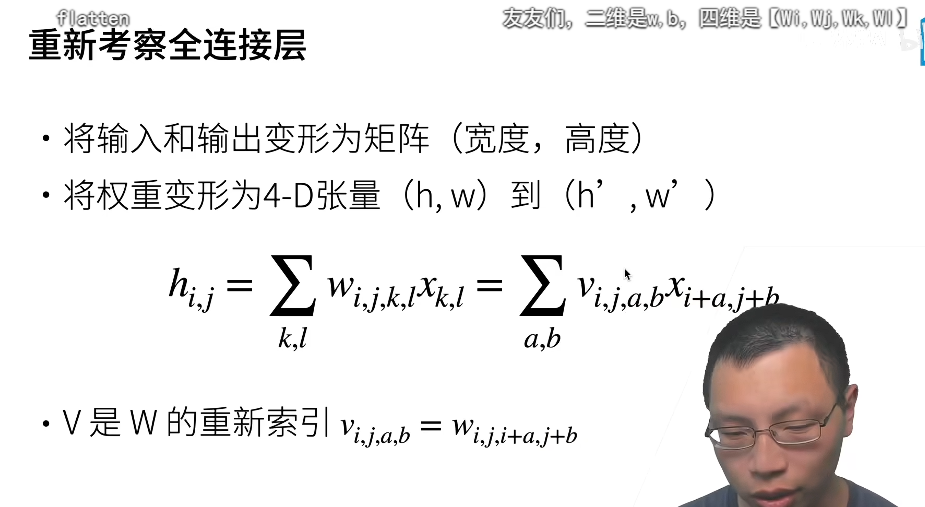

$h_ij$是输出，W是权重矩阵，$W_ij$是矩阵第i行第j列的一个值（矢量），这个矢量是二维矩阵，所以权重矩阵就是四维

因为输出由一维变成二维，所以权重矩阵的元素变为二维，所以权重矩阵变为4维

i,j对应filter内参数的位置，k,l是输入矩阵输入特征的位置，第一个等号说明一个Wi,j要和所有特征相乘

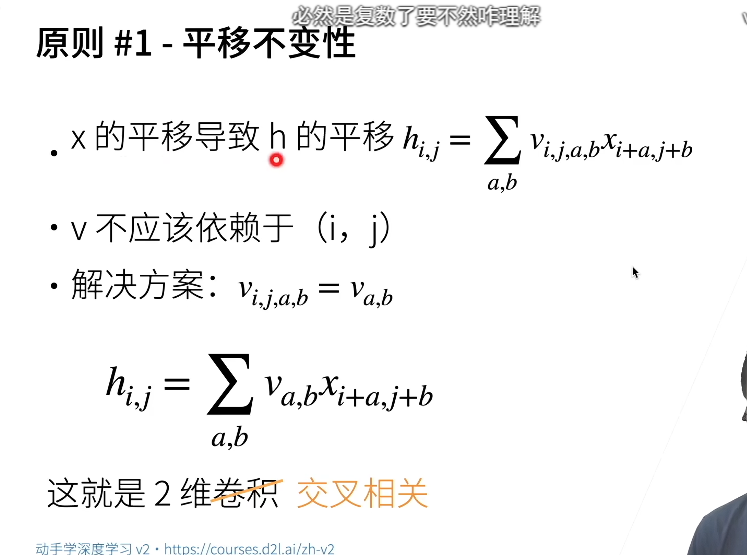

i,j是特征 a,b是位移，v是卷积核

**卷积核不依赖于当前图片的位置(i,j)，仅取决于自己，具有平移不变性**

 所以让v对(i,j)不变，只随(a,b)变

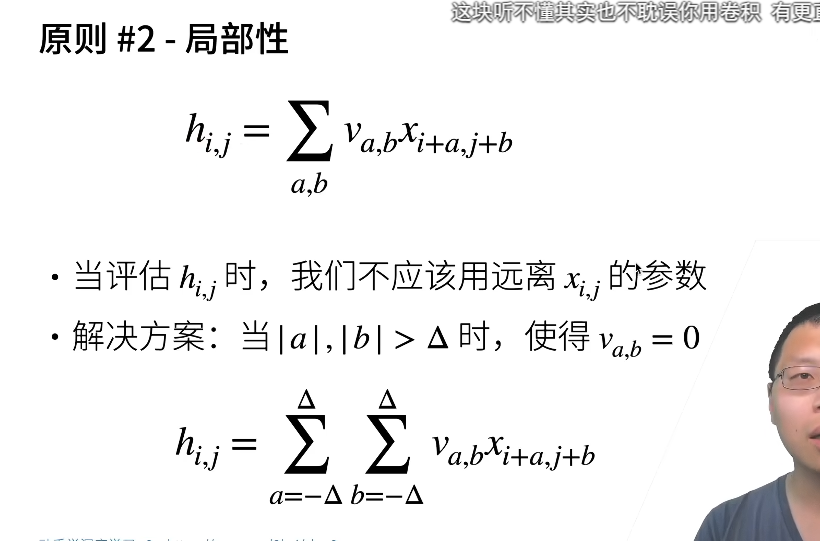

**卷积核不应太大**

卷积运行仅取决于当时的图像位置(卷积核大小)，具有局部性。

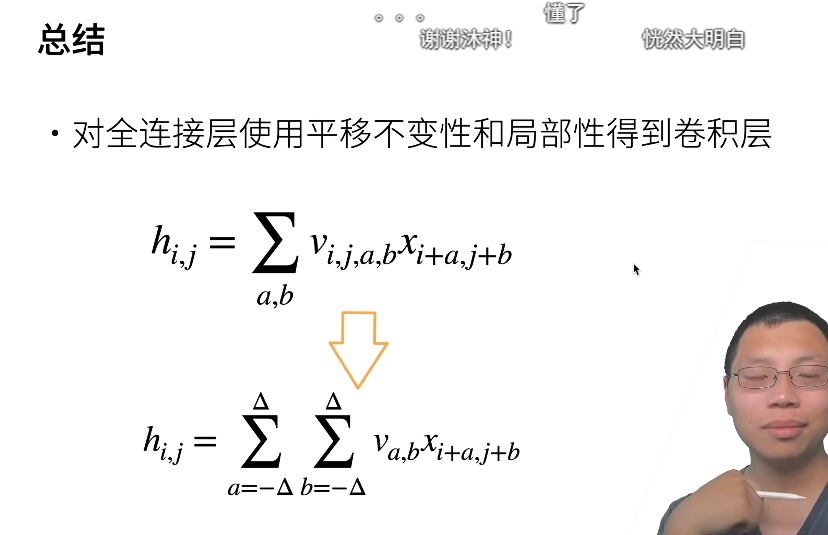

拓展学习：

https://www.bilibili.com/video/BV1VV411478E/?from=search&seid=1725700777641154181&spm_id_from=333.788.comment.all.click&vd_source=c86288548edd2f1c9703f6ffd318fa53

卷积是当前像素点的周围像素点对当前像素点的影响总和

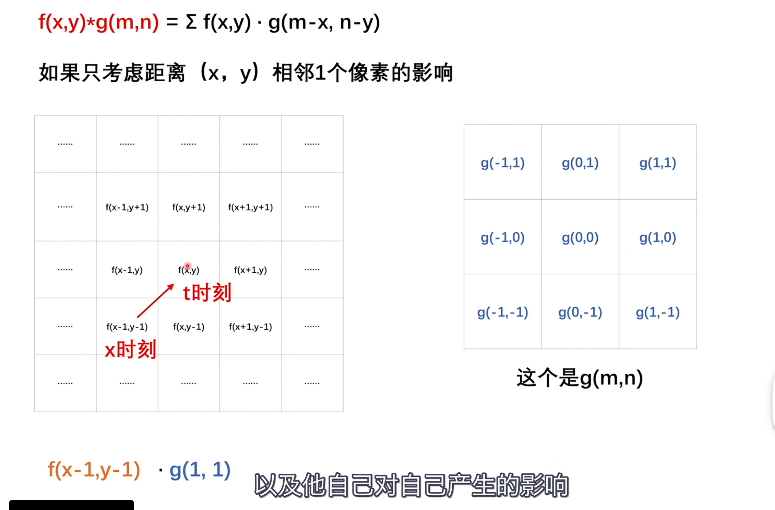

x,y会变化，m,n不会变化，g()的值会随x,y的变化而变化，上图中 m=n=0 处求卷积，其中 x=x-1,y=y-1 时，g(m-x,n-y)=g(1,1)

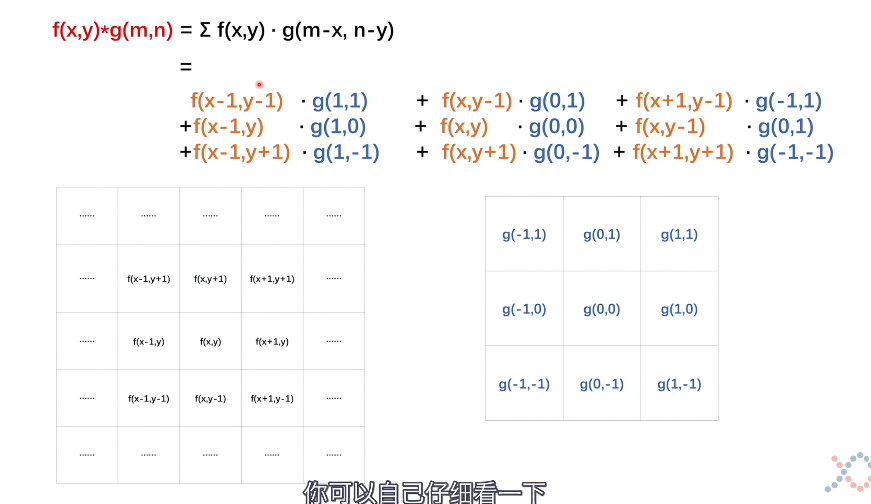

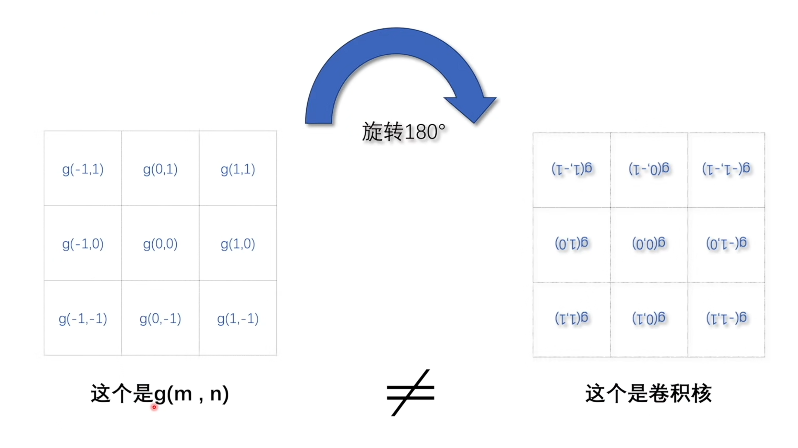

g(m,n) 旋转180° = 卷积核

**卷积**：
1. 不稳定输入，稳定输出，求系统存量
2. 周围像素点如何产生影响
3. 一个像素点如何试探（筛选图像特征）

## 卷积层

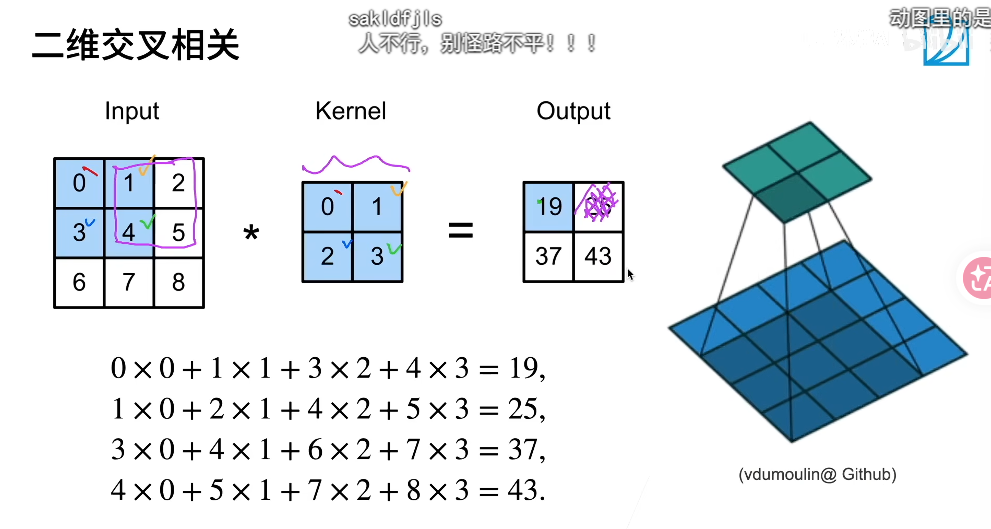

对应位置相乘再相加

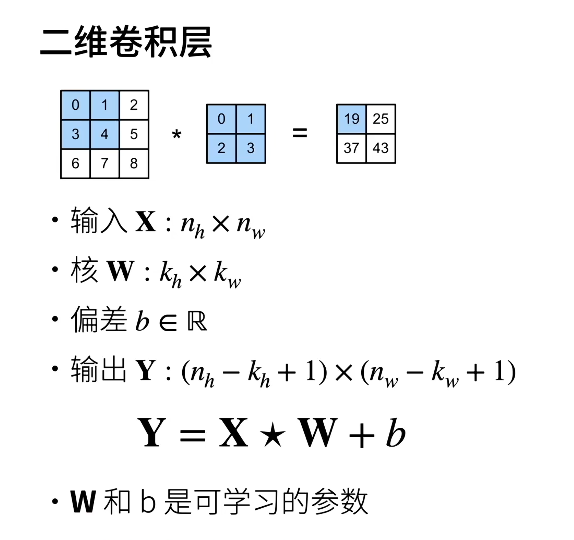

输出Y是指矩阵大小

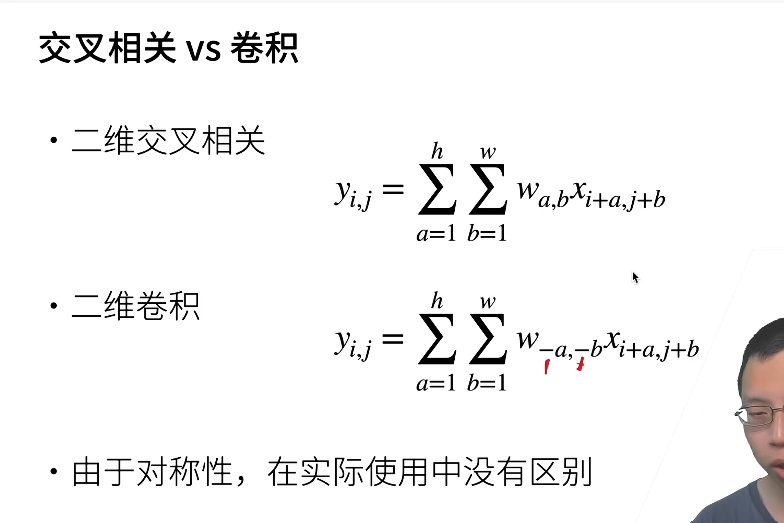

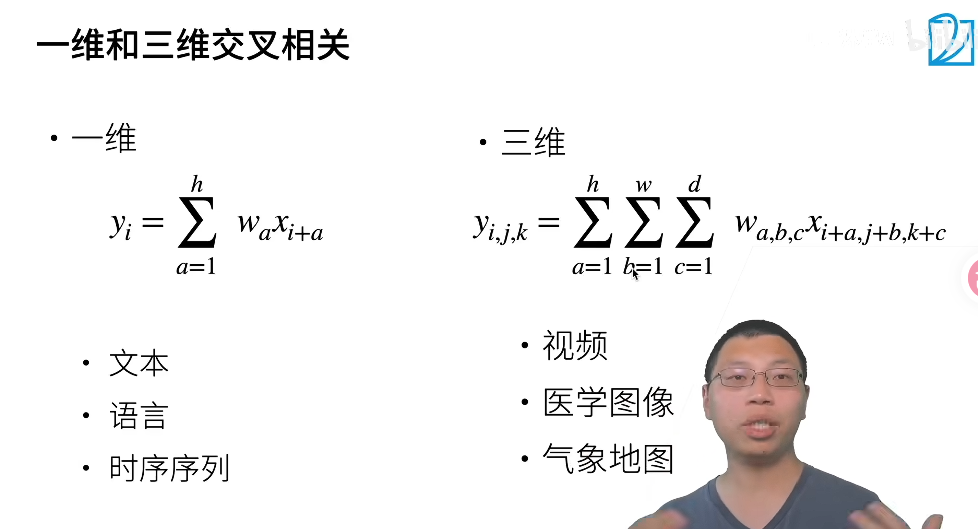

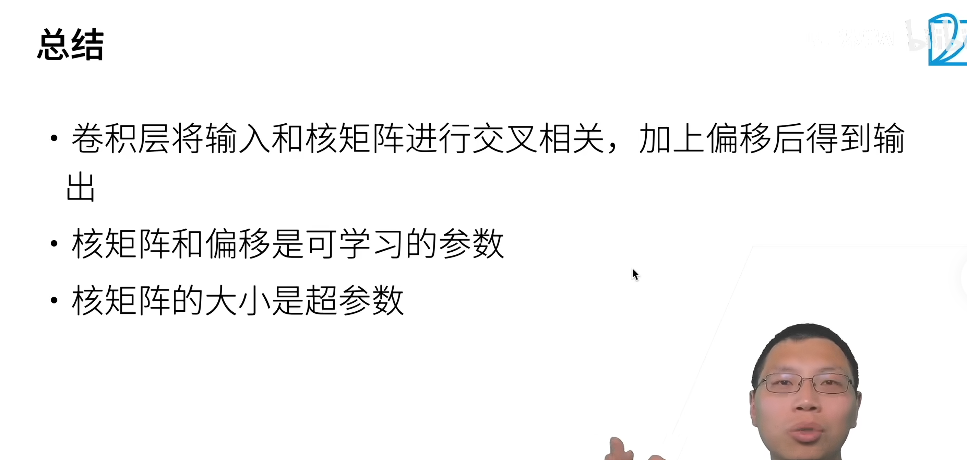

## 代码

互相关运算

In [1]:
import torch
from torch import nn
from d2l import torch as d2l

In [ ]:
def corr2d(X, K): #@save
    """计算⼆维互相关运算"""
    h, w = K.shape
    Y = torch.zeros((X.shape[0] - h + 1, X.shape[1] - w + 1))
    for i in range(Y.shape[0]):
        for j in range(Y.shape[1]):
            Y[i, j] = (X[i:i + h, j:j + w] * K).sum()
            #X[i:i + h, j:j + w]是要计算的小区域，K是卷积核
    return Y

In [3]:
X = torch.tensor([[0.0, 1.0, 2.0], [3.0, 4.0, 5.0], [6.0, 7.0, 8.0]])
K = torch.tensor([[0.0, 1.0], [2.0, 3.0]])
corr2d(X, K)

tensor([[19., 25.],
        [37., 43.]])

卷积层

In [ ]:
class Conv2D(nn.Module):
    def __init__(self, kernel_size):  #kernel_size是超参数
        super().__init__()
        self.weight = nn.Parameter(torch.rand(kernel_size))
        self.bias = nn.Parameter(torch.zeros(1))
    def forward(self, x):
        return corr2d(x, self.weight) + self.bias

边缘检测

In [5]:
X = torch.ones((6, 8))
X[:, 2:6] = 0
X

tensor([[1., 1., 0., 0., 0., 0., 1., 1.],
        [1., 1., 0., 0., 0., 0., 1., 1.],
        [1., 1., 0., 0., 0., 0., 1., 1.],
        [1., 1., 0., 0., 0., 0., 1., 1.],
        [1., 1., 0., 0., 0., 0., 1., 1.],
        [1., 1., 0., 0., 0., 0., 1., 1.]])

In [6]:
K = torch.tensor([[1.0, -1.0]])

In [ ]:
Y = corr2d(X, K)
Y
# 输出Y中的 1代表从⽩⾊到⿊⾊的边缘
# -1代表从⿊⾊到⽩⾊的边缘，其他情况的输出为0。

tensor([[ 0.,  1.,  0.,  0.,  0., -1.,  0.],
        [ 0.,  1.,  0.,  0.,  0., -1.,  0.],
        [ 0.,  1.,  0.,  0.,  0., -1.,  0.],
        [ 0.,  1.,  0.,  0.,  0., -1.,  0.],
        [ 0.,  1.,  0.,  0.,  0., -1.,  0.],
        [ 0.,  1.,  0.,  0.,  0., -1.,  0.]])

In [ ]:
corr2d(X.t(), K)
# 卷积核K只可以检测垂直边缘，⽆法检测⽔平边缘。

tensor([[0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.]])

学习卷积核：学习由X生成Y的卷积核

In [9]:
# 构造⼀个⼆维卷积层，它具有1个输出通道和形状为（1，2）的卷积核
conv2d = nn.Conv2d(1,1, kernel_size=(1, 2), bias=False)
# 这个⼆维卷积层使⽤四维输⼊和输出格式（批量⼤⼩、通道、⾼度、宽度），
# 其中批量⼤⼩和通道数都为1

X = X.reshape((1, 1, 6, 8))
Y = Y.reshape((1, 1, 6, 7))

lr = 3e-2 # 学习率
for i in range(10):
    Y_hat = conv2d(X)
    l = (Y_hat - Y) ** 2   #loss
    conv2d.zero_grad()
    l.sum().backward()
    # 迭代卷积核
    conv2d.weight.data[:] -= lr * conv2d.weight.grad  #梯度下降
    if (i + 1) % 2 == 0:
        print(f'epoch {i+1}, loss {l.sum():.3f}')

epoch 2, loss 8.179
epoch 4, loss 1.434
epoch 6, loss 0.266
epoch 8, loss 0.055
epoch 10, loss 0.013


In [ ]:
# 学到的卷积核参数
conv2d.weight.data.reshape((1, 2))

tensor([[ 0.9941, -0.9766]])